# Evaluation - LogReg Lasso


## Setup

In [21]:
# Magic Codes 
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# IMPORTS

from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.cleaning import clean_data

import us_used_vehicle_resales as wg  
import joblib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay

In [23]:
# SETTINGS

# Global Notebook Style
display(HTML("<style>table { margin-left: 0 !important; }</style>"))

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

In [28]:
# CONSTANTS

DATA_PATH_RAW = '../data/01_raw/'

DATA_PATH_INPUT  = '../data/02_interim/'
DATA_PATH_OUTPUT = '../data/03_processed/'
MODEL_PATH       = '../data/04_models/export/434_Log-Reg-Lasso-432_all_in_with_noise.joblib'
#MODEL_PATH       = '../data/04_models/export/432_reconstructed_402_lasso_all_in.joblib'

tracker = wg.ModelTracker()    


DATA_TYPES = {
    'IsBadBuy': 'int8',
    'PurchDate': 'float64',
    'Auction': 'category',
    'VehYear': 'int16',
    'VehicleAge': 'int8',
    'Make': 'category',
    'Model': 'category',
    'Trim': 'category',
    'SubModel': 'category',
    'Color': 'category',
    'Transmission': 'category',
    'WheelTypeID': 'category',
    'WheelType': 'category',
    'VehOdo': 'int64',
    'Nationality': 'category',
    'Size': 'category',
    'TopThreeAmericanName': 'category',
    'MMRAcquisitionAuctionAveragePrice': 'float64',
    'MMRAcquisitionAuctionCleanPrice': 'float64',
    'MMRAcquisitionRetailAveragePrice': 'float64',
    'MMRAcquisitonRetailCleanPrice': 'float64',
    'MMRCurrentAuctionAveragePrice': 'float64',
    'MMRCurrentAuctionCleanPrice': 'float64',
    'MMRCurrentRetailAveragePrice': 'float64',
    'MMRCurrentRetailCleanPrice': 'float64',
    'PRIMEUNIT': 'category',
    'AUCGUART': 'category',
    'BYRNO': 'category',
    'VNZIP1': 'category',
    'VNST': 'category',
    'VehBCost': 'float64',
    'IsOnlineSale': 'int8',
    'WarrantyCost': 'float64'
}


## Best Model Loading

In [29]:
# LOADING MODEL

wg.print_header('Loading Final Model')

best_model = joblib.load(MODEL_PATH)
print(f"Favorite Modell erfolgreich aus \n{MODEL_PATH} \ngeladen.")

wg.print_footer()




~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
LOADING FINAL MODEL
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Favorite Modell erfolgreich aus 
../data/04_models/export/434_Log-Reg-Lasso-432_all_in_with_noise.joblib 
geladen.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




## Rekonstruktion

In [44]:
import joblib
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.base import clone
import pprint



# ── 1. Überblick ──────────────────────────────────────────────
print("═══ PIPELINE ÜBERBLICK ════════════════════════════════════")
print(best_model)

# ── 2. Alle Steps mit Typ ─────────────────────────────────────
print("\n═══ STEPS ══════════════════════════════════════════════════")
for name, step in best_model.steps:
    print(f"  [{name}]  →  {type(step).__name__}")

# ── 3. Parameter jedes Steps ─────────────────────────────────
print("\n═══ PARAMETER PRO STEP ═════════════════════════════════════")
for name, step in best_model.steps:
    print(f"\n  ── {name} ({type(step).__name__}) ──")
    pprint.pprint(step.get_params(), indent=4)

# ── 4. Alle Parameter flach (z.B. für GridSearch) ────────────
print("\n═══ ALLE PARAMETER (flach) ═════════════════════════════════")
pprint.pprint(best_model.get_params(), indent=2)

# ── 5. Feature Names (wenn Preprocessor vorhanden) ───────────
print("\n═══ FEATURE NAMES ══════════════════════════════════════════")
for name, step in best_model.steps:
    if hasattr(step, "get_feature_names_out"):
        try:
            features = step.get_feature_names_out()
            print(f"  {name}: {list(features[:10])} ..."
                  if len(features) > 10 else f"  {name}: {list(features)}")
        except Exception as e:
            print(f"  {name}: Nicht verfügbar ({e})")

# ── 6. Letzter Estimator (Modell) ─────────────────────────────
print("\n═══ FINALER ESTIMATOR ══════════════════════════════════════")
final = best_model[-1]
print(f"  Typ: {type(final).__name__}")

if hasattr(final, "feature_importances_"):
    print("\n  → Feature Importances (Top 15):")
    importances = pd.Series(final.feature_importances_)
    print(importances.sort_values(ascending=False).head(15).to_string())

elif hasattr(final, "coef_"):
    print(f"\n  → Koeffizienten shape: {np.array(final.coef_).shape}")
    print(f"  → Intercept: {final.intercept_}")

if hasattr(final, "classes_"):
    print(f"  → Klassen: {final.classes_}")

if hasattr(final, "n_features_in_"):
    print(f"  → Input-Features: {final.n_features_in_}")


═══ PIPELINE ÜBERBLICK ════════════════════════════════════
Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['VehicleAge', 'VehOdo', 'VehBCost', 'WarrantyCost',
       'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice',
       'feat_miles_per_year', 'feat_price_ratio', 'feat_price_diff',
       'feat_market_trend', 'feat_warranty_ratio', 'IsOnlineSale'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotE...gnore',
                                                                sparse_output=False),
                                                  Index(['feat_age_group', 'feat_odo_risk', 'feat_price_cat',
       'feat_warranty_peak', 'Make', 'Model', 'Trim', 'SubModel', 'VNZIP1',
       'Auction', 'WheelType', 'Color', 'Transmission', 'Nationality', 'Size'],
      dtype='obje

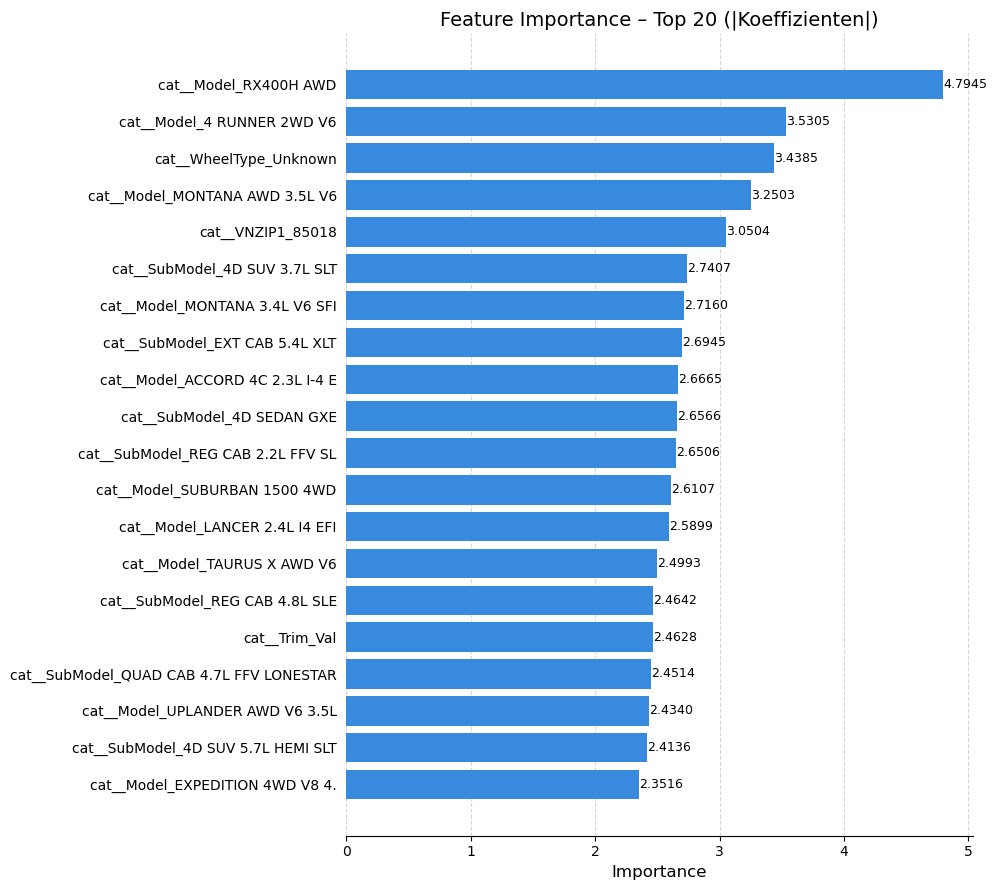

In [47]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# ── Feature-Namen aus Pipeline holen ─────────────────────────
def get_feature_names(pipeline):
    for name, step in pipeline.steps[:-1]:
        if hasattr(step, "get_feature_names_out"):
            try:
                return step.get_feature_names_out()
            except:
                pass
    return None

final   = best_model[-1]
feat_names = get_feature_names(best_model)

# ── Importances ermitteln (tree-based & linear) ───────────────
if hasattr(final, "feature_importances_"):
    importances = final.feature_importances_
    title_suffix = "(Gini / MDI)"
elif hasattr(final, "coef_"):
    importances = np.abs(final.coef_).flatten()
    title_suffix = "(|Koeffizienten|)"
else:
    raise ValueError("Kein feature_importances_ oder coef_ gefunden.")

# Index-Labels fallback
labels = (feat_names if feat_names is not None
          else [f"Feature {i}" for i in range(len(importances))])

top_n = 20
df = (pd.DataFrame({"feature": labels, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(top_n))

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 1))
bars = ax.barh(df["feature"][::-1], df["importance"][::-1],
               color="#378ADD", edgecolor="none")

ax.set_xlabel("Importance", fontsize=12)
ax.set_title(f"Feature Importance – Top {top_n} {title_suffix}", fontsize=14)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# Wert am Ende jedes Balkens
for bar, val in zip(bars, df["importance"][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


# Predict TEST Data 

In [30]:
# PROCESS TEST DATA

X_test_interim = pd.read_parquet(DATA_PATH_INPUT+'features_test.parquet')
y_test = pd.read_parquet(DATA_PATH_INPUT+'target_test.parquet')

# 3. PROCESSING (Exakt die gleiche Kette wie bei Train!)
# Schritt A: Cleaning
X_test_cleaned = clean_data(X_test_interim)

# Schritt B: Feature Engineering (Hier entstehen feat_price_ratio etc.)
X_test_final = engineer_features(X_test_cleaned)

# 4. SAVE TO PROCESSED
wg.save_processed_data(X_test_final, y_test, folder=DATA_PATH_OUTPUT, name='test')

print("✅ Test-Set synchronisiert und bereit für Evaluation!")





# LOADING DATA

wg.print_header('Loading Test Data')

DATA_PATH_PROCESSED = '../data/03_processed/'

X_test = pd.read_parquet(f'{DATA_PATH_PROCESSED}X_test_final.parquet')
y_test = pd.read_parquet(f'{DATA_PATH_PROCESSED}y_test.parquet').iloc[:, 0]

print(f"Daten erfolgreich geladen.")
print(f"Features: {X_test.shape[0]} Zeilen | {X_test.shape[1]} Spalten")
print(f"Target:   '{y_test.name}' (BadBuy-Rate: {y_test.mean():.2%})")

wg.print_footer()





# PREDICTION

wg.print_header("Final Prediction with Test-Data")

y_pred_test = best_model.predict(X_test)

print(classification_report(y_test, y_pred_test))

wg.print_footer()

 DATA CLEANING & SUCCESS REPORT 
KAPITEL 1: COMPLETENESS
  - Erkannt:  26602 kategoriale Lücken
  - Aktion:   26602 gefüllt mit 'Unknown'

KAPITEL 2: INTEGRITY
  - Erkannt:    175 Logik-Fehler (< 100$, Alter, Odo)
  - Aktion:     175 geheilt via Imputation
  - Aktion:       0 unrettbar gelöscht
-------------------------------------------------------
ENDERGEBNIS:
  - Datensätze (Rows):  13124
  - Retention Rate:    100.00%
  - Churn Rate:          0.00%

 FEATURE ENGINEERING REPORT 
Status: Enrichment Complete
Added Features (9):
   [+] feat_price_ratio
   [+] feat_price_diff
   [+] feat_market_trend
   [+] feat_miles_per_year
   [+] feat_warranty_ratio
   [+] feat_age_group
   [+] feat_odo_risk
   [+] feat_price_cat
   [+] feat_warranty_peak
Total Columns now: 41

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PROCESSED TEST DATA EXPORT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 X-Features: 13124 rows | 41 cols
🎯 y-Labels:   Gespeichert (13124 Zeilen)
📂 Location:   ../data/03_processed/
~~~~

# Predict AIM Data

In [31]:
# ==========================================
# PREDICT AIM DATA (THE FINALE)
# ==========================================

wg.print_header('Predict AIM Data')

# 1. LOADING
wg.print_title('Loading Data')
X_aim_raw = pd.read_csv(
    '../data/01_raw/features_aim.csv',
    dtype=DATA_TYPES,
    sep=';'
)
X_aim_raw['PurchDate'] = pd.to_datetime(X_aim_raw['PurchDate'], unit='s')

print(f"Daten erfolgreich geladen: {X_aim_raw.shape[0]} Zeilen")

# 2. PROCESSING
wg.print_title('Cleaning Data')
X_aim_cleaned = clean_data(X_aim_raw)

wg.print_title('Engineering Features')
X_aim_final = engineer_features(X_aim_cleaned)

print(X_aim_final.dtypes)



# 3. PREDICT TARGET
wg.print_title("Final Prediction with AIM-Data")

# Wir nutzen direkt X_aim_final aus dem Speicher
y_pred_aim = best_model.predict(X_aim_final)

# 4. EXPORT RESULTS
predictions_df = pd.DataFrame({'IsBadBuy': y_pred_aim})
predictions_df.to_csv('../data/05_results/predictions_aim.csv', index=False)





wg.print_title("Summary of AIM-Predictions")

summary_df = predictions_df['IsBadBuy'].value_counts().reset_index()
summary_df.columns = ['Status', 'Count']
summary_df['Label'] = summary_df['Status'].map({0: '✅ Good Buys', 1: '⚠️ Bad Buys'})
summary_df['Percentage'] = (summary_df['Count'] / len(predictions_df) * 100).round(2)
display_df = summary_df[['Label', 'Count', 'Percentage']].copy()
display_df['Percentage'] = display_df['Percentage'].astype(str) + " %"

print(f"FINALE VORHERSAGE: {len(predictions_df)} Fahrzeuge analysiert")
wg.print_seperator()
print(display_df.to_string(index=False, justify='left'))
wg.print_seperator()

bad_count = summary_df.loc[summary_df['Status'] == 1, 'Count'].values[0]
bad_perc = summary_df.loc[summary_df['Status'] == 1, 'Percentage'].values[0]

print(f"Ergebnis: Dein Modell rät bei {bad_perc}% der Autos zur Vorsicht.")
print(f"Datei exportiert nach: ../data/05_results/predictions_aim.csv")

wg.print_footer()






~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PREDICT AIM DATA
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Loading Data
----------------------------------------
Daten erfolgreich geladen: 7292 Zeilen

Cleaning Data
----------------------------------------
 DATA CLEANING & SUCCESS REPORT 
KAPITEL 1: COMPLETENESS
  - Erkannt:  14767 kategoriale Lücken
  - Aktion:   14767 gefüllt mit 'Unknown'

KAPITEL 2: INTEGRITY
  - Erkannt:     91 Logik-Fehler (< 100$, Alter, Odo)
  - Aktion:      91 geheilt via Imputation
  - Aktion:       0 unrettbar gelöscht
-------------------------------------------------------
ENDERGEBNIS:
  - Datensätze (Rows):   7292
  - Retention Rate:    100.00%
  - Churn Rate:          0.00%


Engineering Features
----------------------------------------
 FEATURE ENGINEERING REPORT 
Status: Enrichment Complete
Added Features (9):
   [+] feat_price_ratio
   [+] feat_price_diff
   [+] feat_market_trend
   [+] feat_miles_per_year
   [+] feat_warranty_ratio
   [+] feat_age_group
  